# Resultados da ablação

Análise pós-treino (rode `2_run_ablation.py` antes).

| Seção | O que compara |
|-------|----------------|
| **0. Auditoria** | Contagem wide→final (raw vs mrmr_stable) |
| **1. Eficiência** | Barras mean ± SD; heatmaps e tabela (AUC, BAcc, F1, …) — 1 PDF por painel |
| **2. Consistência** | Frequência de seleção + linhas T1/T2/T3 — 1 PDF por config/modelo |

**Runs:** `SELECTION_MODE` × `WITH_COMBAT` → 4 execuções típicas.

**Entrada:** `csvs/longitudinal_4_groups/ablation_results/{modality}/`


In [15]:
# 4 runs típicos: SELECTION_MODE raw|mrmr_stable × WITH_COMBAT False|True

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from ablation_analysis import (
    feature_freq_table,
    feature_freq_table_grouped,
    filter_ablation_config,
    filter_temporally_stable,
    plot_temporal_lines_on_ax,
    prepare_ablation_df,
    selection_audit_report,
    summarize_selection_audit,
)

# --- mudar entre runs ---
SELECTION_MODE = "mrmr_stable"  # raw | mrmr_stable
WITH_COMBAT = True             # True | False | None

# --- §2 consistência ---
STAB_MODE = "topk"              # topk | single | overview
STAB_CFG = ("smci_pmci", "texture", "svm", False)  # só se STAB_MODE == "single"
STAB_TOP_K = 1
STAB_TOP_N = 25

SAVE_FIGS = False
EXPECTED_FOLDS = 5

MODALITIES = None  # ex.: ("vol", "shape")

MODEL_ORDER = ["svm", "rf", "mlp"]
MOD_ORDER = ["vol", "shape", "texture", "disp", "all"]
TASK_ORDER = ["cn_ad", "cn_smci", "smci_pmci", "smci_ad", "cn_pmci", "pmci_ad"]
TASK_LABELS = {
    "cn_ad": "CN × AD",
    "cn_smci": "CN × sMCI",
    "smci_pmci": "sMCI × pMCI",
    "smci_ad": "sMCI × AD",
    "cn_pmci": "CN × pMCI",
    "pmci_ad": "pMCI × AD",
}
COLOR_MODEL = {"svm": "#4477AA", "rf": "#EE6677", "mlp": "#228833"}
COLOR_MOD = {"vol": "#4477AA", "shape": "#EE6677", "texture": "#228833", "disp": "#CCBB44", "all": "#AA3377"}
EXTRA_METRICS = (
    ("bal_acc_mean", "bal_acc_std", "BAcc"),
    ("f1_pos_mean", "f1_pos_std", "F1"),
    ("sens_pos_mean", "sens_pos_std", "Sens"),
    ("spec_neg_mean", "spec_neg_std", "Spec"),
)
ALL_METRICS = (
    ("auc_mean", "auc_std", "AUC"),
    ("accuracy_mean", "accuracy_std", "Acc"),
    ("auc_pr_mean", "auc_pr_std", "AUC-PR"),
    ("bal_acc_mean", "bal_acc_std", "BAcc"),
    ("mcc_mean", "mcc_std", "MCC"),
    ("f1_pos_mean", "f1_pos_std", "F1"),
    ("sens_pos_mean", "sens_pos_std", "Sens"),
    ("spec_neg_mean", "spec_neg_std", "Spec"),
)

RESULTS_ROOT = Path("csvs/longitudinal_4_groups/ablation_results")
FIGURES_DIR = RESULTS_ROOT / "figures" / SELECTION_MODE
FIGURES_STAB_DIR = FIGURES_DIR / "stability"


def resolve_csv(mod_dir: Path, stem: str) -> Path:
    for name in (f"{stem}_{SELECTION_MODE}.csv", f"{stem}.csv"):
        path = mod_dir / name
        if path.is_file():
            return path
    raise FileNotFoundError(f"{stem} ausente em {mod_dir} (selection={SELECTION_MODE})")


def available_modalities(root: Path) -> list[str]:
    mods = []
    for p in sorted(root.iterdir()):
        if not p.is_dir() or p.name in ("figures",):
            continue
        try:
            resolve_csv(p, "ablation_summary")
            mods.append(p.name)
        except FileNotFoundError:
            pass
    return mods


def load_summaries(modalities: list[str]) -> pd.DataFrame:
    frames = [pd.read_csv(resolve_csv(RESULTS_ROOT / m, "ablation_summary")) for m in modalities]
    return pd.concat(frames, ignore_index=True)


def load_ablation(modalities: list[str]) -> pd.DataFrame:
    frames = [pd.read_csv(resolve_csv(RESULTS_ROOT / m, "ablation_results_all")) for m in modalities]
    return prepare_ablation_df(pd.concat(frames, ignore_index=True))


def prep_df(df: pd.DataFrame, *, filter_run: bool = True) -> pd.DataFrame:
    out = df.copy()
    if filter_run:
        if "selection_mode" in out.columns:
            out = out[out["selection_mode"].astype(str) == SELECTION_MODE]
        if WITH_COMBAT is not None:
            out = out[out["with_combat"] == WITH_COMBAT]
    out["task_label"] = out["task"].map(TASK_LABELS).fillna(out["task"])
    out["model_key"] = pd.Categorical(out["model_key"].astype(str), categories=MODEL_ORDER, ordered=True)
    out["modality"] = pd.Categorical(out["modality"].astype(str), categories=MOD_ORDER, ordered=True)
    present_tasks = [t for t in TASK_ORDER if t in set(out["task"])]
    out["task"] = pd.Categorical(out["task"].astype(str), categories=present_tasks, ordered=True)
    return out.dropna(subset=["task", "model_key", "modality"])


def build_rank_table(df: pd.DataFrame) -> pd.DataFrame:
    """Tabela completa: todas as configs, métricas mean±SD, ordem auc_pooled → bal_acc_mean."""
    rank_cols = [
        "task_label", "modality", "model_key", "with_combat", "selection_mode",
        "auc_pooled", "n_features_mean",
    ]
    rank_cols += [c for mean_col, std_col, _ in ALL_METRICS for c in (mean_col, std_col)]
    rank_cols = [c for c in rank_cols if c in df.columns]
    sort_cols = [c for c in ("auc_pooled", "bal_acc_mean") if c in df.columns]
    rank = df.sort_values(sort_cols, ascending=False)[rank_cols].copy()
    for mean_col, std_col, label in ALL_METRICS:
        if mean_col in rank.columns and std_col in rank.columns:
            rank[f"{label}±std"] = rank.apply(
                lambda r, m=mean_col, s=std_col: fmt_mean_std(r[m], r[s]), axis=1,
            )
    return rank


def rank_show_cols(rank: pd.DataFrame) -> list[str]:
    cols = [
        "task_label", "modality", "model_key", "with_combat", "selection_mode",
        "auc_pooled", "n_features_mean",
    ]
    cols += [f"{label}±std" for _, _, label in ALL_METRICS if f"{label}±std" in rank.columns]
    return [c for c in cols if c in rank.columns]


def save_fig(fig, name: str, *, subdir: Path | None = None) -> Path:
    out_dir = subdir or FIGURES_DIR
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / f"{name}.pdf"
    if SAVE_FIGS:
        fig.savefig(path, format="pdf", dpi=150, bbox_inches="tight")
        print(f"Salvo: {path}")
    return path


def fmt_mean_std(mean: float, std: float, digits: int = 3) -> str:
    return f"{mean:.{digits}f}±{std:.{digits}f}"


LOADED_MODALITIES = MODALITIES or available_modalities(RESULTS_ROOT)
if not LOADED_MODALITIES:
    raise FileNotFoundError(f"Nenhuma modalidade com summary em {RESULTS_ROOT}")

summary_raw = load_summaries(LOADED_MODALITIES)
df_ablation = load_ablation(LOADED_MODALITIES)
all_results_df = prep_df(summary_raw, filter_run=False)
plot_df = prep_df(summary_raw)
fold_df = prep_df(df_ablation)
rank_table = build_rank_table(all_results_df)

combat_tag = {True: "combat", False: "nocombat", None: "all"}[WITH_COMBAT]
print(f"Modalidades: {LOADED_MODALITIES}")
print(f"Plots filtrados: {SELECTION_MODE} | ComBat: {WITH_COMBAT}")
print(f"Configs (plots): {len(plot_df)} | Folds: {len(fold_df)} | Tabela completa: {len(rank_table)}")
print(f"Figuras §1: {FIGURES_DIR}")
print(f"Figuras §2: {FIGURES_STAB_DIR}")


Modalidades: ['all', 'disp', 'shape', 'texture', 'vol']
Plots filtrados: mrmr_stable | ComBat: True
Configs (plots): 90 | Folds: 4500 | Tabela completa: 360
Figuras §1: csvs/longitudinal_4_groups/ablation_results/figures/mrmr_stable
Figuras §2: csvs/longitudinal_4_groups/ablation_results/figures/mrmr_stable/stability


## 0. Auditoria de seleção

Usa `STAB_CFG` (task, modalidade, modelo, combat). Compara modos de seleção no CSV.


In [16]:
audit_task, audit_mod, audit_model, audit_combat = STAB_CFG

audit_sub = df_ablation[
    (df_ablation["task"].astype(str) == audit_task)
    & (df_ablation["model_key"].astype(str) == audit_model)
    & (df_ablation["with_combat"] == audit_combat)
    & (df_ablation["modality"].astype(str) == audit_mod)
]
audit_modes = tuple(sorted(audit_sub["selection_mode"].astype(str).unique()))

display(selection_audit_report(
    df_ablation,
    task=audit_task,
    model=audit_model,
    with_combat=audit_combat,
    modality=audit_mod,
    selection_modes=audit_modes,
))

# display(summarize_selection_audit(audit_sub[audit_sub["selection_mode"].astype(str).isin(audit_modes)]).head(10))



[mrmr_stable] smci_pmci | texture | svm | combat=False
  wide (inicial):     450 colunas
  após pool estável:  28.7 (média folds)
  após corr/var:      26.5 (média folds)
  selecionados final: 26.5 (média) | min=16 max=33
  removidos pool estável (435): ['L | T1_original_glcm_ClusterProminence', 'L | T1_original_glcm_ClusterShade', 'L | T1_original_glcm_ClusterTendency', 'L | T1_original_glcm_Contrast', 'L | T1_original_glcm_Correlation', 'L | T1_original_glcm_DifferenceAverage', 'L | T1_original_glcm_DifferenceVariance', 'L | T1_original_glcm_Id', 'L | T1_original_glcm_Idm', 'L | T1_original_glcm_Idmn', 'L | T1_original_glcm_Idn', 'L | T1_original_glcm_Imc1']
  removidos corr/var (15): ['L | T1_original_glcm_DifferenceAverage', 'L | T1_original_glcm_Imc2', 'L | T1_original_glcm_JointEnergy', 'L | T1_original_glrlm_LongRunLowGrayLevelEmphasis', 'L | T2_original_glcm_Imc2', 'L | T2_original_gldm_DependenceVariance', 'L | T2_original_gldm_LargeDependenceHighGrayLevelEmphasis', 'L | T3_o

,selection_mode,n_wide,n_final_mean,n_removidos_mean
0,mrmr_stable,450,26.5,423.5
1,raw,450,450.0,0.0


In [17]:
MODS = ["vol", "shape", "texture", "disp"]
STAGES = [
    ("n_features_raw", "wide"),
    ("n_features_after_stable_pool", "após mrmr"),
    ("n_features_after_filters", "após corr/var"),
    ("n_features_selected", "final"),
]

sub = df_ablation[
    df_ablation["modality"].astype(str).isin(MODS)
    & (df_ablation["with_combat"] == WITH_COMBAT)
].copy()

rows = []
for (mod, mode), g in sub.groupby(["modality", "selection_mode"], sort=True):
    row = {"modality": mod, "selection_mode": mode}
    for col, label in STAGES:
        if col in g.columns:
            row[label] = round(g[col].mean(), 1)
    rows.append(row)

feat_summary = pd.DataFrame(rows).sort_values(["modality", "selection_mode"])
display(feat_summary)

,modality,selection_mode,wide,após mrmr,após corr/var,final
0,disp,mrmr_stable,720.0,145.3,144.1,144.1
1,disp,raw,720.0,720.0,720.0,720.0
2,shape,mrmr_stable,84.0,58.3,45.2,45.2
3,shape,raw,84.0,84.0,84.0,84.0
4,texture,mrmr_stable,450.0,38.2,35.9,35.9
5,texture,raw,450.0,450.0,450.0,450.0
6,vol,mrmr_stable,18.0,14.8,14.6,14.6
7,vol,raw,18.0,18.0,18.0,18.0


## 1. Eficiência dos modelos

Helpers na célula abaixo; **execução com 1 chamada por tarefa/modelo** — edite `title` e `fname`.


In [18]:
# --- §1 Eficiência: estilo e helpers ---

@dataclass
class PlotStyle:
    title_size: int = 11
    label_size: int = 10
    tick_size: int = 8
    annot_size: int = 8
    heatmap_fig: tuple[float, float] = (5.2, 3.8)
    bar_fig: tuple[float, float] = (4.5, 4.0)
    cmap: str = "YlOrRd"
    ref_line: float | None = 0.5


EFF_STYLE = PlotStyle()


def _cat_levels(series: pd.Series, preferred: list | None = None) -> list:
    if hasattr(series, "cat"):
        levels = list(series.cat.categories)
    else:
        levels = sorted(series.dropna().unique())
    if preferred:
        return [v for v in preferred if v in set(levels)] + [v for v in levels if v not in set(preferred)]
    return levels


def _pivot_mean_std(sub: pd.DataFrame, mean_col: str, std_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    mean_w = sub.pivot_table(index="model_key", columns="modality", values=mean_col, aggfunc="first", observed=True)
    std_w = sub.pivot_table(index="model_key", columns="modality", values=std_col, aggfunc="first", observed=True)
    mean_w = mean_w.reindex(index=MODEL_ORDER, columns=[m for m in MOD_ORDER if m in mean_w.columns])
    std_w = std_w.reindex(index=MODEL_ORDER, columns=mean_w.columns)
    return mean_w, std_w


def plot_heatmap_task(
    df: pd.DataFrame,
    task_id: str,
    *,
    title: str,
    fname: str,
    mean_col: str = "auc_mean",
    std_col: str = "auc_std",
    vmin: float = 0.5,
    vmax: float = 1.0,
    digits: int = 2,
    cbar_label: str = "AUC (média)",
    style: PlotStyle = EFF_STYLE,
):
    """1 heatmap — edite title e fname."""
    sub = df[df["task"].astype(str) == task_id]
    if sub.empty:
        print(f"Sem dados: {task_id}")
        return
    fig, ax = plt.subplots(figsize=style.heatmap_fig)
    mean_w, std_w = _pivot_mean_std(sub, mean_col, std_col)
    annot = mean_w.copy().astype(object)
    for r in annot.index:
        for c in annot.columns:
            m, s = mean_w.loc[r, c], std_w.loc[r, c]
            annot.loc[r, c] = "" if pd.isna(m) else fmt_mean_std(float(m), float(s), digits)
    sns.heatmap(
        mean_w.astype(float), annot=annot.values, fmt="", cmap=style.cmap,
        vmin=vmin, vmax=vmax, ax=ax, cbar=True, cbar_kws={"label": cbar_label},
        annot_kws={"fontsize": style.annot_size},
    )
    ax.set_title(title, fontsize=style.title_size)
    plt.tight_layout()
    save_fig(fig, fname)
    plt.show()
    plt.close(fig)


def plot_bars(
    data: pd.DataFrame,
    panel: str,
    *,
    col: str,
    title: str,
    fname: str,
    y: str = "auc",
    ylabel: str = "AUC (mean ± SD)",
    x: str = "modality",
    hue: str = "task_label",
    ymin: float = 0.4,
    ymax: float = 1.0,
    errorbar: str | None = "sd",
    style: PlotStyle = EFF_STYLE,
):
    """1 painel de barras — edite title e fname."""
    sub = data.dropna(subset=[x, hue, col, y])
    part = sub[sub[col].astype(str) == str(panel)]
    if part.empty:
        print(f"Sem dados: {panel}")
        return
    fig, ax = plt.subplots(figsize=style.bar_fig)
    order = _cat_levels(
        part[x],
        MOD_ORDER if x == "modality"
        else TASK_ORDER if x == "task"
        else [TASK_LABELS[t] for t in TASK_ORDER] if x == "task_label"
        else None,
    )
    hue_pref = MODEL_ORDER if hue == "model_key" else MOD_ORDER if hue == "modality" else None
    hue_order = _cat_levels(part[hue], hue_pref)
    palette = COLOR_MODEL if hue == "model_key" else (COLOR_MOD if hue == "modality" else None)
    sns.barplot(
        data=part, x=x, y=y, hue=hue,
        order=order, hue_order=hue_order, palette=palette,
        ax=ax, errorbar=errorbar,
        capsize=0.15 if errorbar is not None else 0,
    )
    ax.set_title(str(panel), fontsize=style.label_size)
    ax.set_ylabel(ylabel, fontsize=style.label_size)
    ax.set_ylim(ymin, ymax)
    if style.ref_line is not None:
        ax.axhline(style.ref_line, color="gray", ls="--", lw=0.8)
    ax.tick_params(axis="x", rotation=25, labelsize=style.tick_size)
    ax.tick_params(axis="y", labelsize=style.tick_size)
    ax.legend(fontsize=style.tick_size, loc="best")
    fig.suptitle(title, fontsize=style.title_size)
    plt.tight_layout()
    save_fig(fig, fname)
    plt.show()
    plt.close(fig)


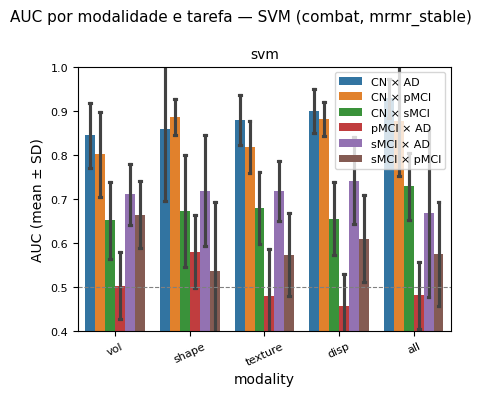

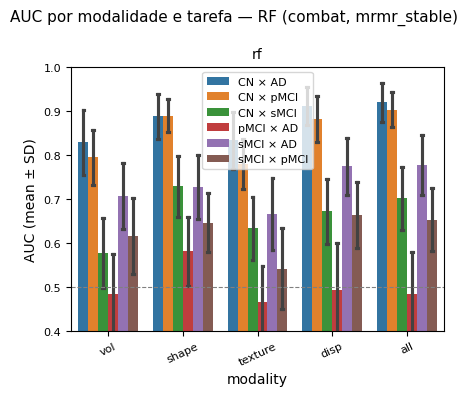

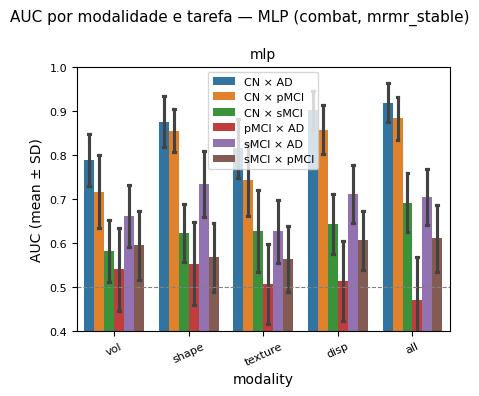

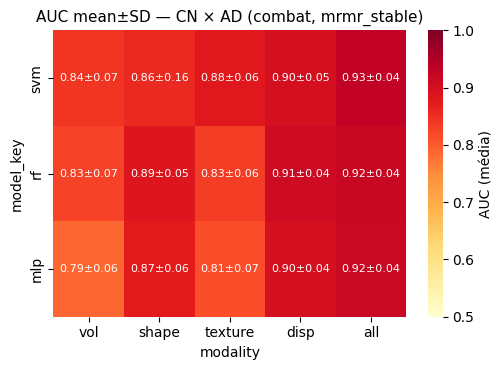

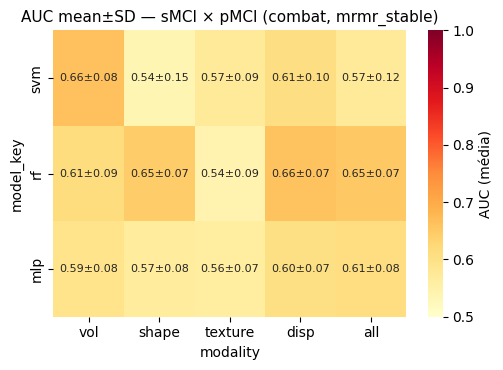


Tabela completa (360 configs): todas as abordagens (selection_mode × with_combat), ordenada por auc_pooled ↓, desempate bal_acc_mean ↓


,task_label,modality,model_key,with_combat,selection_mode,auc_pooled,n_features_mean,AUC±std,Acc±std,AUC-PR±std,BAcc±std,MCC±std,F1±std,Sens±std,Spec±std
0,CN × AD,all,rf,False,mrmr_stable,0.923629,186.44,0.928±0.038,0.860±0.045,0.902±0.050,0.854±0.048,0.710±0.093,0.816±0.061,0.828±0.098,0.879±0.069
1,CN × AD,all,svm,True,mrmr_stable,0.922345,199.94,0.928±0.044,0.855±0.050,0.891±0.066,0.853±0.052,0.706±0.101,0.814±0.064,0.844±0.108,0.861±0.080
2,CN × AD,all,svm,False,mrmr_stable,0.917801,186.44,0.925±0.040,0.847±0.050,0.889±0.063,0.844±0.055,0.689±0.105,0.802±0.067,0.830±0.117,0.858±0.078
3,CN × AD,all,rf,True,mrmr_stable,0.915395,199.94,0.919±0.044,0.868±0.046,0.896±0.051,0.857±0.055,0.722±0.102,0.821±0.070,0.810±0.106,0.904±0.049
4,CN × AD,all,mlp,True,mrmr_stable,0.914971,199.94,0.918±0.044,0.840±0.051,0.878±0.067,0.839±0.055,0.676±0.105,0.796±0.067,0.831±0.114,0.846±0.079
72,CN × AD,disp,rf,False,mrmr_stable,0.912320,140.98,0.915±0.043,0.845±0.053,0.879±0.065,0.834±0.062,0.677±0.116,0.791±0.079,0.787±0.123,0.881±0.066
5,CN × AD,all,mlp,False,mrmr_stable,0.908063,186.44,0.910±0.045,0.838±0.044,0.866±0.072,0.834±0.048,0.667±0.090,0.791±0.060,0.819±0.102,0.849±0.069
73,CN × AD,disp,rf,True,mrmr_stable,0.907911,141.02,0.911±0.043,0.841±0.054,0.878±0.061,0.830±0.062,0.668±0.119,0.787±0.078,0.787±0.120,0.873±0.067
6,CN × AD,all,rf,False,raw,0.906106,1416.00,0.912±0.041,0.845±0.047,0.893±0.046,0.834±0.048,0.676±0.096,0.794±0.061,0.790±0.092,0.878±0.076
74,CN × AD,disp,mlp,False,raw,0.903557,720.00,0.910±0.040,0.825±0.049,0.877±0.054,0.819±0.053,0.640±0.102,0.773±0.066,0.790±0.109,0.847±0.075


In [19]:
# --- §1 execução: edite title/fname de cada chamada ---

_ct = f"({combat_tag}, {SELECTION_MODE})"

# AUC — barras por modelo
plot_bars(fold_df, "svm", col="model_key",
    title=f"AUC por modalidade e tarefa — SVM {_ct}",
    fname=f"auc_by_model_svm_{combat_tag}",
)
plot_bars(fold_df, "rf", col="model_key",
    title=f"AUC por modalidade e tarefa — RF {_ct}",
    fname=f"auc_by_model_rf_{combat_tag}",
)
plot_bars(fold_df, "mlp", col="model_key",
    title=f"AUC por modalidade e tarefa — MLP {_ct}",
    fname=f"auc_by_model_mlp_{combat_tag}",
)

# AUC — heatmap por tarefa
plot_heatmap_task(plot_df, "cn_ad",
    title=f"AUC mean±SD — CN × AD {_ct}",
    fname=f"auc_heatmap_cn_ad_{combat_tag}",
)
# plot_heatmap_task(plot_df, "cn_smci",
#     title=f"AUC mean±SD — CN × sMCI {_ct}",
#     fname=f"auc_heatmap_cn_smci_{combat_tag}",
# )
plot_heatmap_task(plot_df, "smci_pmci",
    title=f"AUC mean±SD — sMCI × pMCI {_ct}",
    fname=f"auc_heatmap_smci_pmci_{combat_tag}",
)
# plot_heatmap_task(plot_df, "smci_ad",
#     title=f"AUC mean±SD — sMCI × AD {_ct}",
#     fname=f"auc_heatmap_smci_ad_{combat_tag}",
# )
# plot_heatmap_task(plot_df, "cn_pmci",
#     title=f"AUC mean±SD — CN × pMCI {_ct}",
#     fname=f"auc_heatmap_cn_pmci_{combat_tag}",
# )
# plot_heatmap_task(plot_df, "pmci_ad",
#     title=f"AUC mean±SD — pMCI × AD {_ct}",
#     fname=f"auc_heatmap_pmci_ad_{combat_tag}",
# )

# Métricas extras — descomente o bloco que quiser plotar

# # BAcc — heatmaps
# plot_heatmap_task(plot_df, "cn_ad", mean_col="bal_acc_mean", std_col="bal_acc_std",
#     title=f"BAcc mean±SD — CN × AD {_ct}", fname=f"bacc_heatmap_cn_ad_{combat_tag}",
#     vmin=0.4, cbar_label="BAcc (média)")
# ... (repita para cn_smci, smci_pmci, smci_ad, cn_pmci, pmci_ad)

print(
    f"\nTabela completa ({len(rank_table)} configs): "
    "todas as abordagens (selection_mode × with_combat), "
    "ordenada por auc_pooled ↓, desempate bal_acc_mean ↓"
)
pd.set_option("display.max_rows", None)
display(rank_table[rank_show_cols(rank_table)])


## 2. Consistência dos atributos

Helpers abaixo; **execução com 1 chamada por config/modelo** — edite `title` e `fname`.
Rode `topk_configs()` para ver configs sugeridas.


In [20]:
# --- §2 Consistência: estilo e helpers ---

@dataclass
class StabPlotStyle:
    title_size: int = 10
    label_size: int = 9
    tick_size: int = 8
    freq_fig_w: float = 8.0
    freq_bar_h: float = 0.28
    temporal_fig: tuple[float, float] = (5.5, 4.2)
    freq_color: str = "#4477AA"
    grid_pct: tuple[int, ...] = (20, 40, 60, 80)


STAB_STYLE = StabPlotStyle()


def _load_config_df(task_id: str, mod_id: str, model_key: str, with_combat: bool) -> pd.DataFrame:
    sub_all = df_ablation[df_ablation["modality"].astype(str) == mod_id]
    if sub_all.empty:
        raise ValueError(f"sem dados para modalidade {mod_id!r}")
    return filter_ablation_config(
        sub_all,
        task=task_id,
        modality=mod_id,
        model_key=model_key,
        with_combat=with_combat,
        selection_mode=SELECTION_MODE,
        expected_folds=EXPECTED_FOLDS,
    )


def _stable_grouped(df_cfg: pd.DataFrame) -> pd.DataFrame:
    grp = feature_freq_table_grouped(df_cfg)
    return filter_temporally_stable(grp, min_pct=70, min_timepoints=2)


# def _stab_tag(task_id: str, mod_id: str, model_key: str, with_combat: bool) -> str:
#     return f"{task_id}_{mod_id}_{model_key}_{'combat' if with_combat else 'nocombat'}_{SELECTION_MODE}"


def topk_configs() -> pd.DataFrame:
    """Melhor config por tarefa — use para copiar task/mod/model na célula de execução."""
    combats = [False, True] if WITH_COMBAT is None else [WITH_COMBAT]
    top = (
        plot_df.sort_values("auc_pooled", ascending=False)
        .groupby("task", observed=True)
        .head(STAB_TOP_K)
    )
    top = top[top["with_combat"].isin(combats)].copy()
    top["task_label"] = top["task"].astype(str).map(TASK_LABELS).fillna(top["task"])
    return top[["task", "task_label", "modality", "model_key", "with_combat", "auc_pooled"]]


def plot_selection_freq(
    task_id: str,
    mod_id: str,
    model_key: str,
    with_combat: bool,
    *,
    title: str,
    fname: str,
    style: StabPlotStyle = STAB_STYLE,
):
    """Barras de frequência — edite title e fname."""
    df_cfg = _load_config_df(task_id, mod_id, model_key, with_combat)
    freq = feature_freq_table(df_cfg, top_n=STAB_TOP_N)
    if freq.empty:
        print(f"Sem freq: {task_id}/{mod_id}/{model_key}")
        return
    freq = freq.sort_values(["pct", "feature_short"])
    n = len(freq)
    fig, ax = plt.subplots(figsize=(style.freq_fig_w, max(3.2, style.freq_bar_h * n + 1)))
    y = np.arange(n)
    ax.barh(y, freq["pct"], height=0.75, color=style.freq_color, alpha=0.9)
    ax.set_yticks(y)
    ax.set_yticklabels(freq["feature_short"], fontsize=style.tick_size)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Frequência de seleção (%)", fontsize=style.label_size)
    for x in style.grid_pct:
        ax.axvline(x, color="gray", ls="--", lw=0.5, alpha=0.5)
    ax.set_title(title, fontsize=style.title_size)
    plt.tight_layout()
    save_fig(fig, fname, subdir=FIGURES_STAB_DIR)
    plt.show()
    plt.close(fig)


def plot_temporal(
    task_id: str,
    mod_id: str,
    model_key: str,
    with_combat: bool,
    *,
    title: str,
    fname: str,
    style: StabPlotStyle = STAB_STYLE,
):
    """Linhas T1/T2/T3 — edite title e fname."""
    df_cfg = _load_config_df(task_id, mod_id, model_key, with_combat)
    grp_stable = _stable_grouped(df_cfg)
    fig, ax = plt.subplots(figsize=style.temporal_fig)
    ax.set_ylim(0, 105)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["T1", "T2", "T3"], fontsize=style.tick_size)
    ax.set_xlabel("Visita", fontsize=style.label_size)
    ax.set_ylabel("Incidência (% das avaliações externas)", fontsize=style.label_size)
    for y in style.grid_pct:
        ax.axhline(y, color="gray", ls="--", lw=0.4, alpha=0.45)
    if grp_stable.empty:
        ax.set_title(f"{model_key.upper()} (0 estáveis)", fontsize=style.title_size)
        fig.suptitle(title, fontsize=style.title_size + 1)
        plt.tight_layout()
        save_fig(fig, fname, subdir=FIGURES_STAB_DIR)
        plt.show()
        plt.close(fig)
        return
    plot_temporal_lines_on_ax(ax, grp_stable, show_legend=True)
    ax.set_title(f"{model_key.upper()} (n={len(grp_stable)})", fontsize=style.title_size)
    fig.suptitle(title, fontsize=style.title_size + 1)
    plt.tight_layout()
    save_fig(fig, fname, subdir=FIGURES_STAB_DIR)
    plt.show()
    plt.close(fig)


Configs top-k sugeridas (copie task/mod/model abaixo se necessário):


,task,task_label,modality,model_key,with_combat,auc_pooled
1,cn_ad,CN × AD,all,svm,True,0.922345
7,cn_pmci,CN × pMCI,all,rf,True,0.901947
25,smci_ad,sMCI × AD,all,rf,True,0.767600
181,cn_smci,CN × sMCI,shape,rf,True,0.721059
114,smci_pmci,sMCI × pMCI,disp,rf,True,0.656544
202,pmci_ad,pMCI × AD,shape,svm,True,0.572993


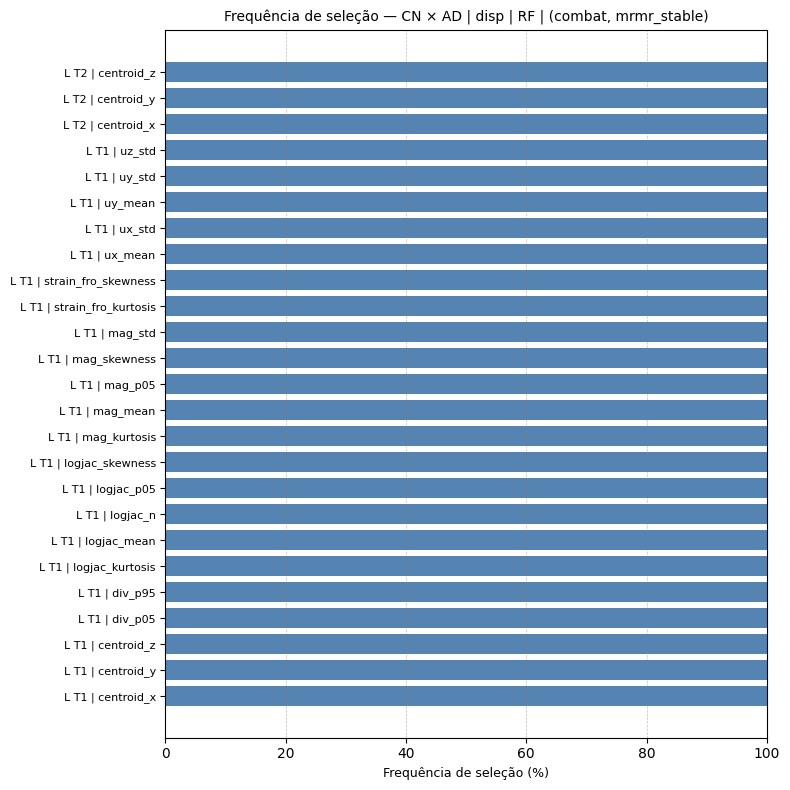

/mnt/study-data/pgirardi/tmp/ipykernel_2503844/3851399305.py:121: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


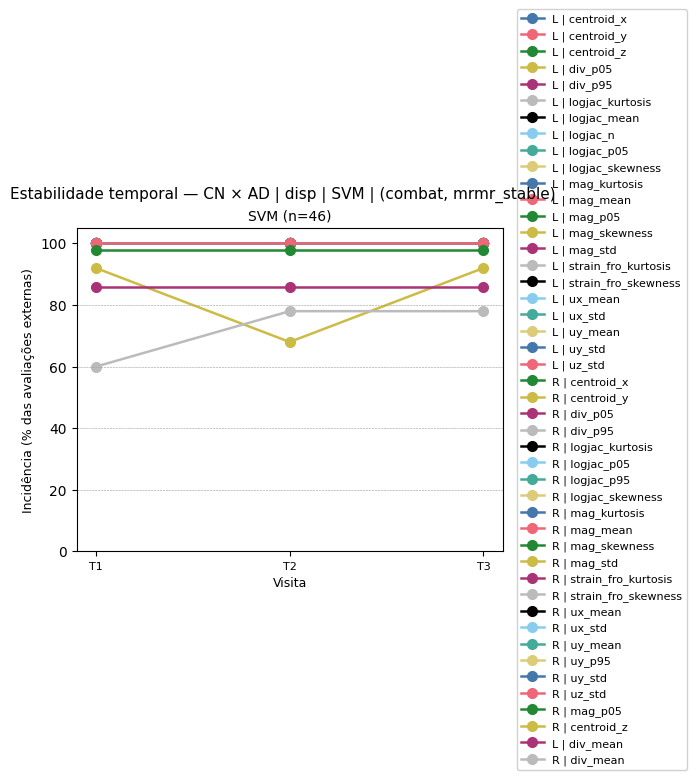

/mnt/study-data/pgirardi/tmp/ipykernel_2503844/3851399305.py:121: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


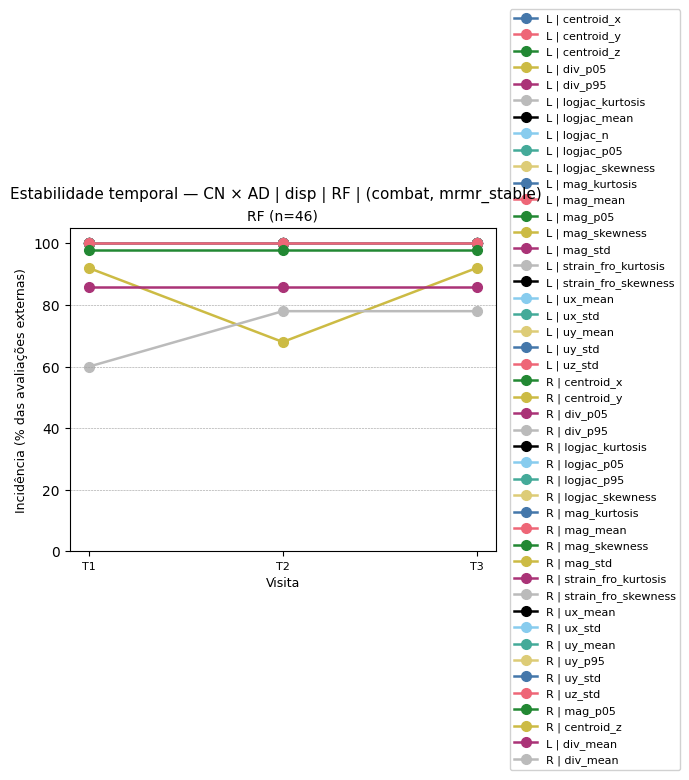

/mnt/study-data/pgirardi/tmp/ipykernel_2503844/3851399305.py:121: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


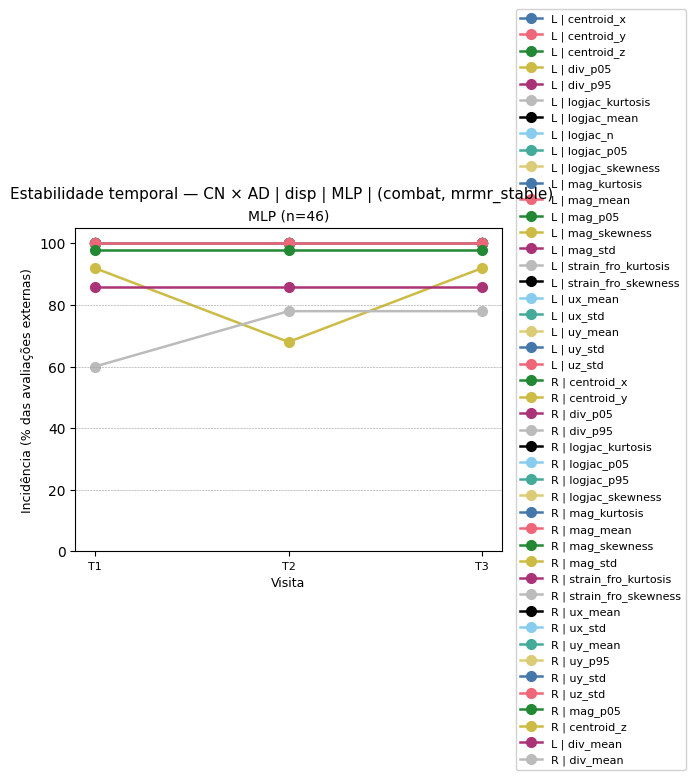

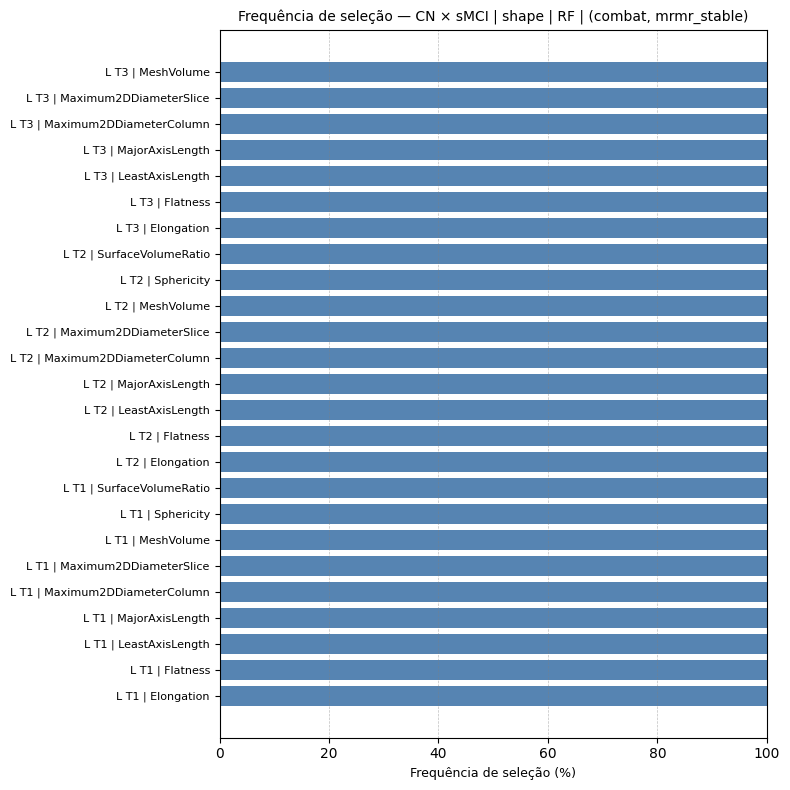

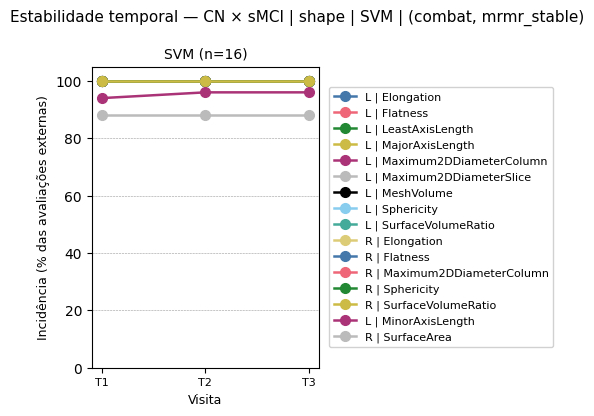

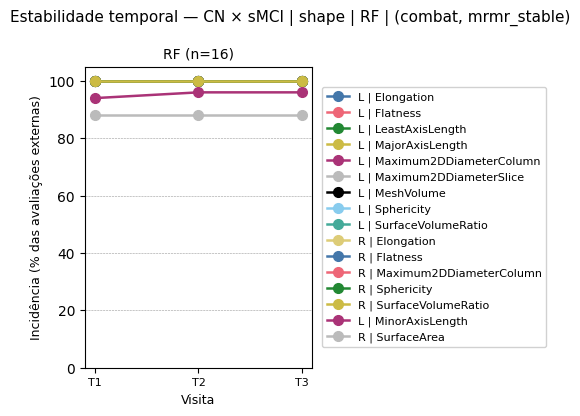

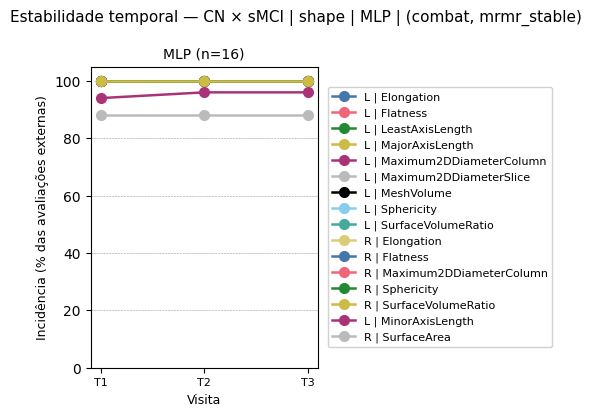

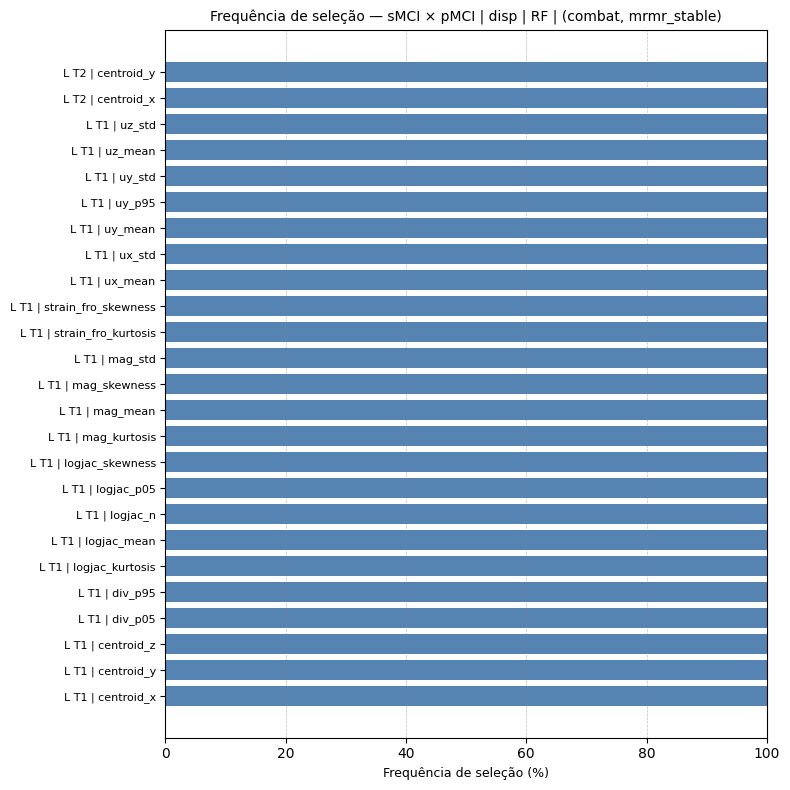

/mnt/study-data/pgirardi/tmp/ipykernel_2503844/3851399305.py:121: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


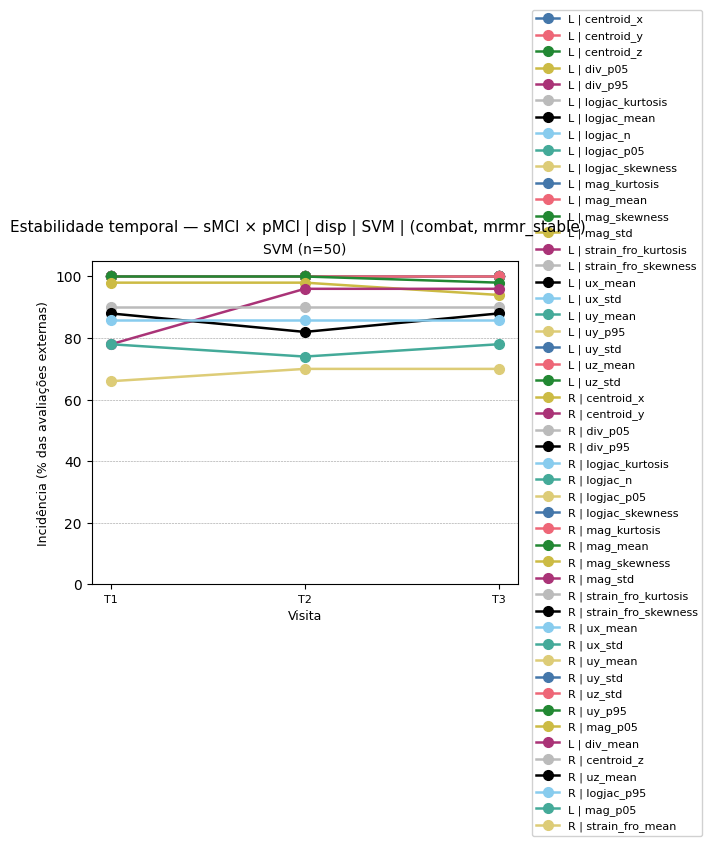

/mnt/study-data/pgirardi/tmp/ipykernel_2503844/3851399305.py:121: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


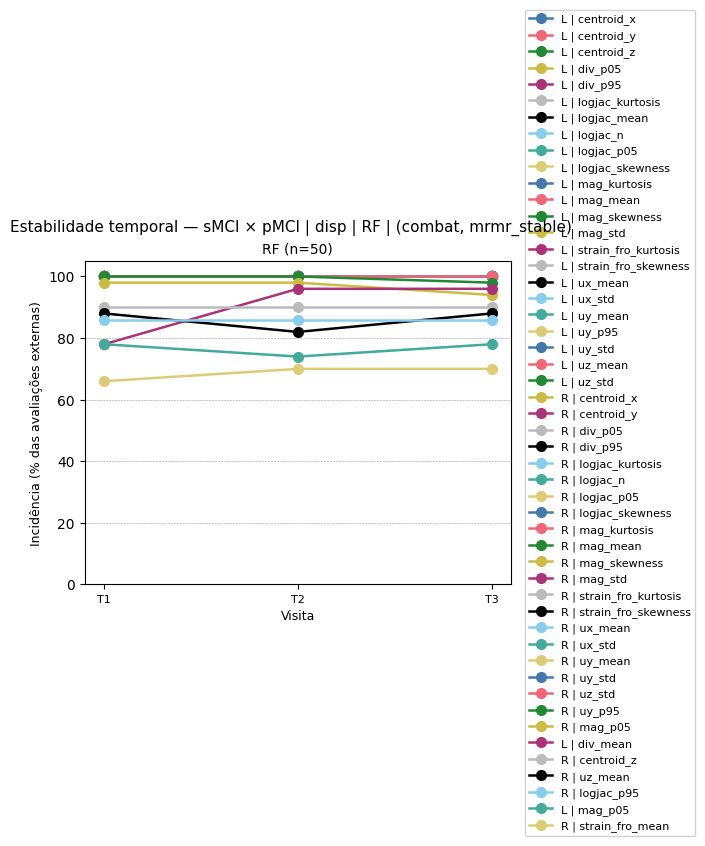

/mnt/study-data/pgirardi/tmp/ipykernel_2503844/3851399305.py:121: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


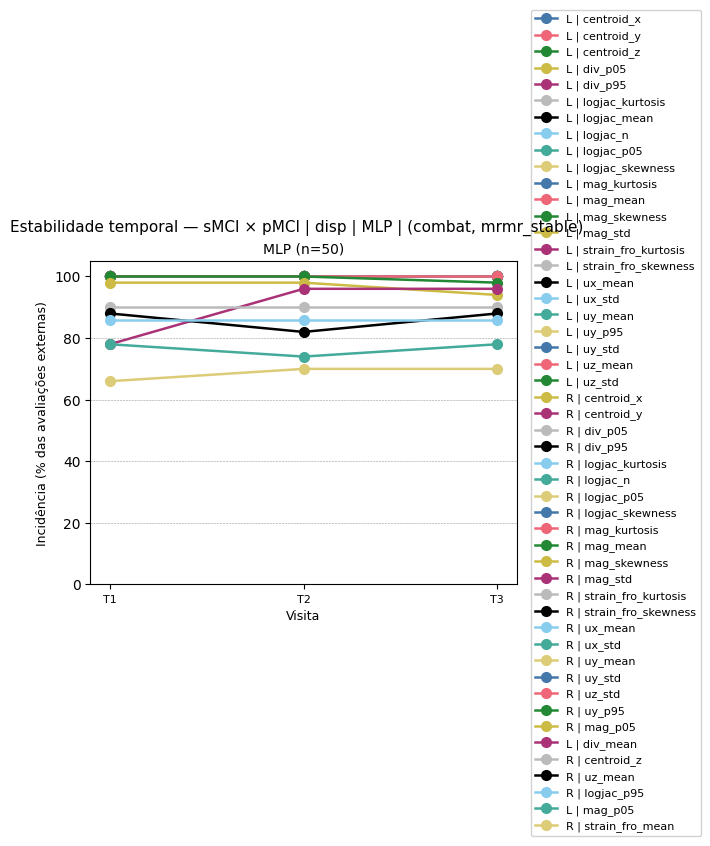

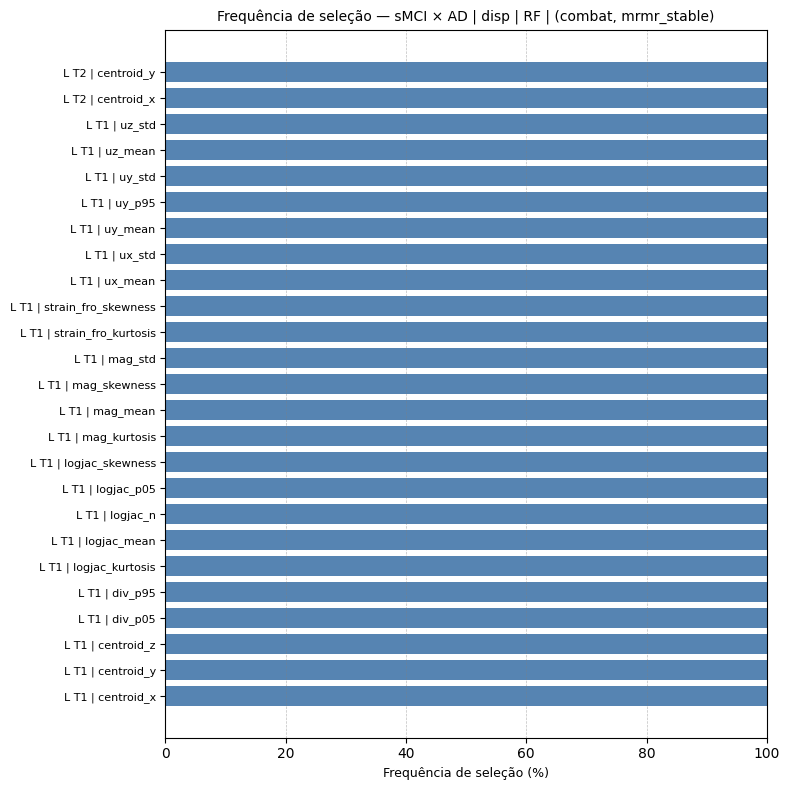

/mnt/study-data/pgirardi/tmp/ipykernel_2503844/3851399305.py:121: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


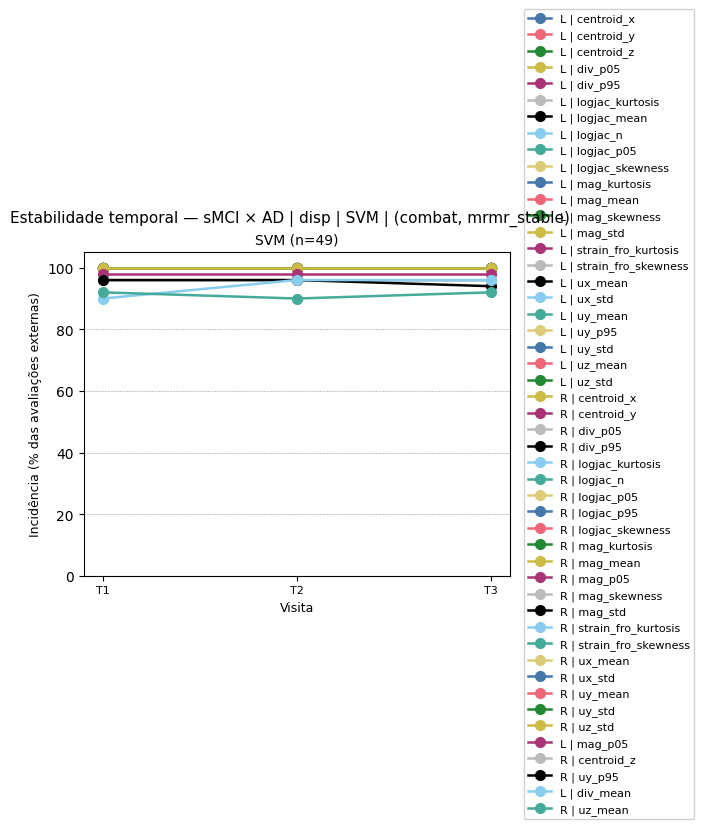

/mnt/study-data/pgirardi/tmp/ipykernel_2503844/3851399305.py:121: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


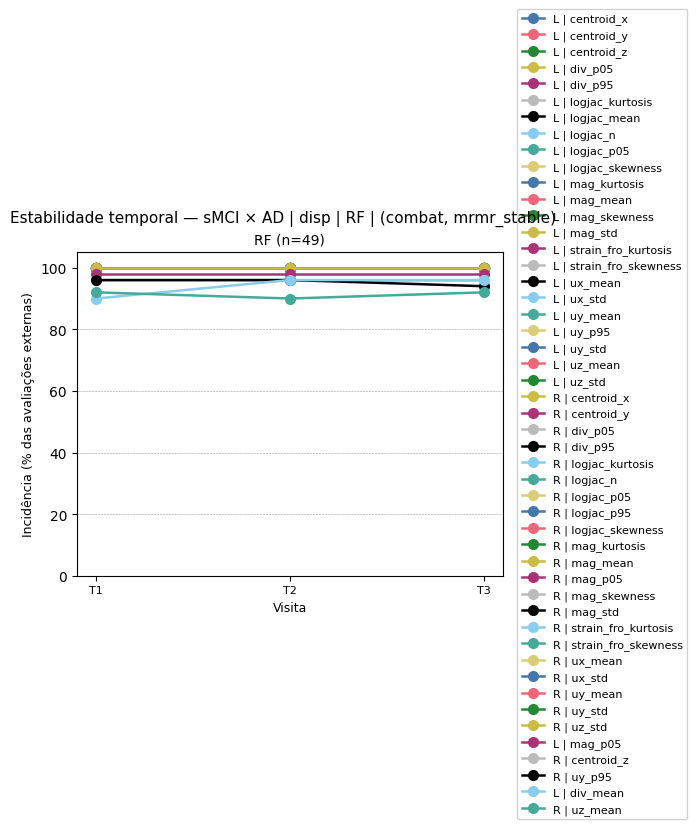

/mnt/study-data/pgirardi/tmp/ipykernel_2503844/3851399305.py:121: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


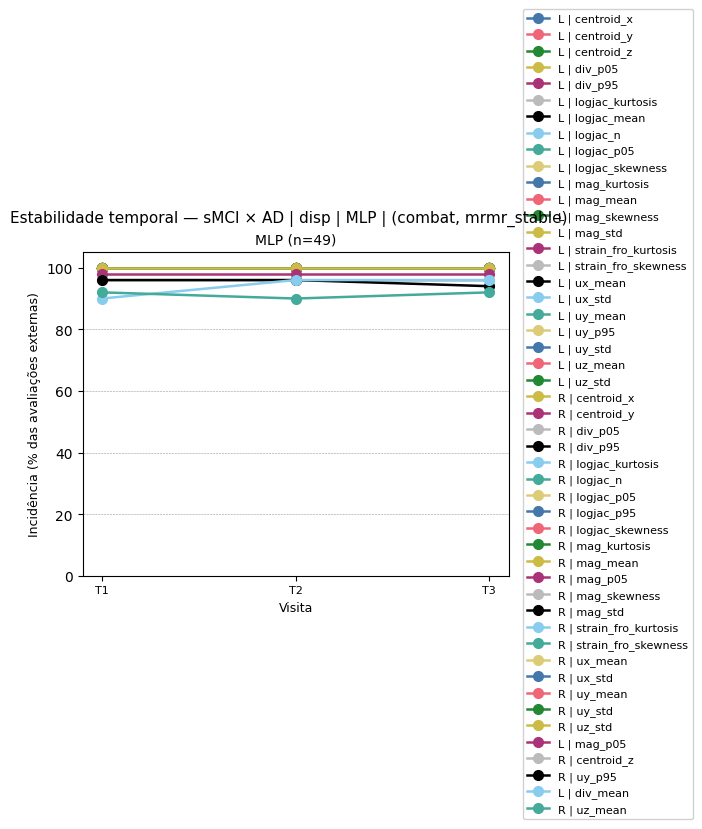

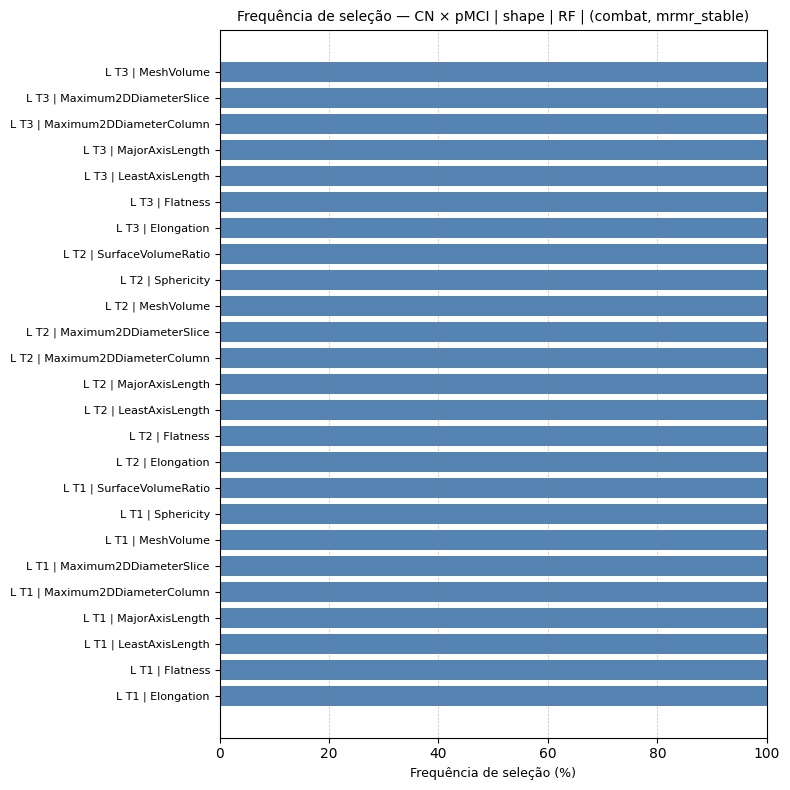

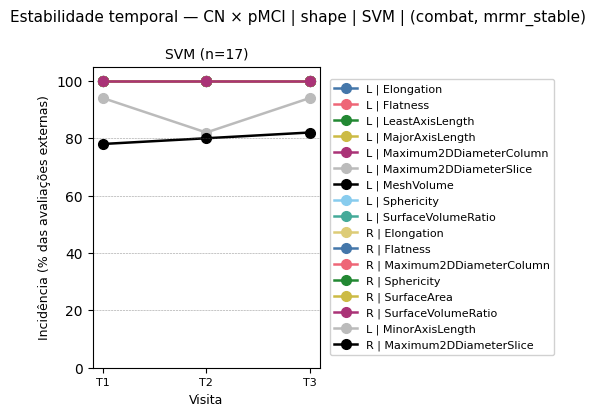

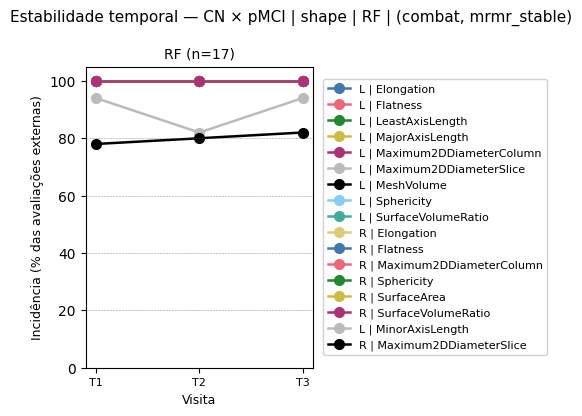

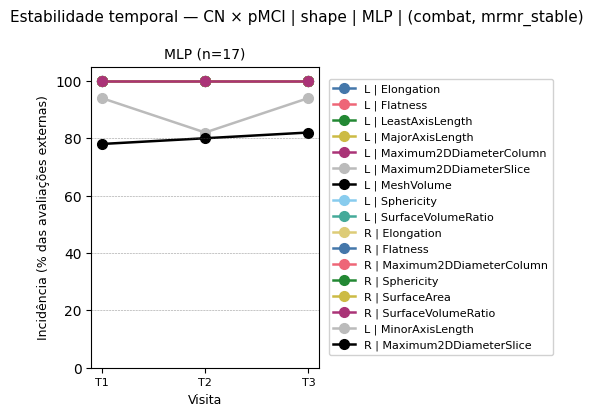

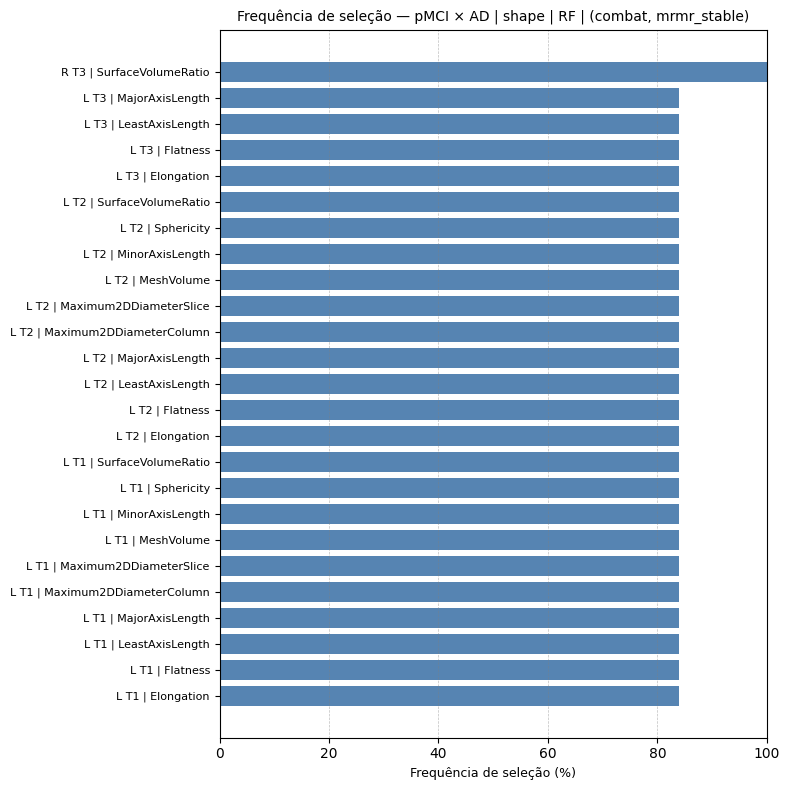

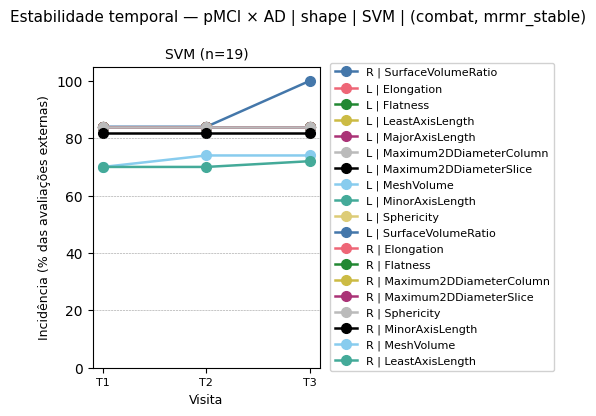

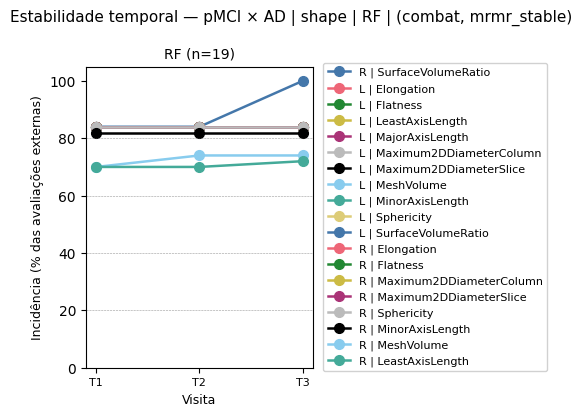

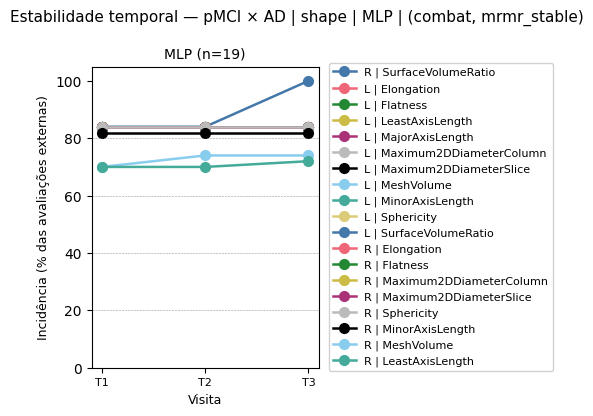

In [21]:
# --- §2 execução: edite title/fname; ajuste task/mod/model conforme topk_configs() ---

if SELECTION_MODE == "raw":
    print("§2: SELECTION_MODE=raw — consistência omitida (use mrmr_stable)")
else:
    print("Configs top-k sugeridas (copie task/mod/model abaixo se necessário):")
    display(topk_configs())

    _wc = WITH_COMBAT if WITH_COMBAT is not None else False
    _ct = f"({'combat' if _wc else 'nocombat'}, {SELECTION_MODE})"

    # --- CN × AD (cn_ad | disp | rf) ---
    plot_selection_freq("cn_ad", "disp", "rf", _wc,
        title=f"Frequência de seleção — CN × AD | disp | RF | {_ct}",
        fname=f"selection_freq_cn_ad_disp_rf_{combat_tag}",
    )
    plot_temporal("cn_ad", "disp", "svm", _wc,
        title=f"Estabilidade temporal — CN × AD | disp | SVM | {_ct}",
        fname=f"temporal_stable_cn_ad_disp_svm_{combat_tag}",
    )
    plot_temporal("cn_ad", "disp", "rf", _wc,
        title=f"Estabilidade temporal — CN × AD | disp | RF | {_ct}",
        fname=f"temporal_stable_cn_ad_disp_rf_{combat_tag}",
    )
    plot_temporal("cn_ad", "disp", "mlp", _wc,
        title=f"Estabilidade temporal — CN × AD | disp | MLP | {_ct}",
        fname=f"temporal_stable_cn_ad_disp_mlp_{combat_tag}",
    )

    # --- CN × sMCI (cn_smci | shape | rf) ---
    plot_selection_freq("cn_smci", "shape", "rf", _wc,
        title=f"Frequência de seleção — CN × sMCI | shape | RF | {_ct}",
        fname=f"selection_freq_cn_smci_shape_rf_{combat_tag}",
    )
    plot_temporal("cn_smci", "shape", "svm", _wc,
        title=f"Estabilidade temporal — CN × sMCI | shape | SVM | {_ct}",
        fname=f"temporal_stable_cn_smci_shape_svm_{combat_tag}",
    )
    plot_temporal("cn_smci", "shape", "rf", _wc,
        title=f"Estabilidade temporal — CN × sMCI | shape | RF | {_ct}",
        fname=f"temporal_stable_cn_smci_shape_rf_{combat_tag}",
    )
    plot_temporal("cn_smci", "shape", "mlp", _wc,
        title=f"Estabilidade temporal — CN × sMCI | shape | MLP | {_ct}",
        fname=f"temporal_stable_cn_smci_shape_mlp_{combat_tag}",
    )

    # --- sMCI × pMCI (smci_pmci | disp | rf) ---
    plot_selection_freq("smci_pmci", "disp", "rf", _wc,
        title=f"Frequência de seleção — sMCI × pMCI | disp | RF | {_ct}",
        fname=f"selection_freq_smci_pmci_disp_rf_{combat_tag}",
    )
    plot_temporal("smci_pmci", "disp", "svm", _wc,
        title=f"Estabilidade temporal — sMCI × pMCI | disp | SVM | {_ct}",
        fname=f"temporal_stable_smci_pmci_disp_svm_{combat_tag}",
    )
    plot_temporal("smci_pmci", "disp", "rf", _wc,
        title=f"Estabilidade temporal — sMCI × pMCI | disp | RF | {_ct}",
        fname=f"temporal_stable_smci_pmci_disp_rf_{combat_tag}",
    )
    plot_temporal("smci_pmci", "disp", "mlp", _wc,
        title=f"Estabilidade temporal — sMCI × pMCI | disp | MLP | {_ct}",
        fname=f"temporal_stable_smci_pmci_disp_mlp_{combat_tag}",
    )

    # --- sMCI × AD (smci_ad | disp | rf) ---
    plot_selection_freq("smci_ad", "disp", "rf", _wc,
        title=f"Frequência de seleção — sMCI × AD | disp | RF | {_ct}",
        fname=f"selection_freq_smci_ad_disp_rf_{combat_tag}",
    )
    plot_temporal("smci_ad", "disp", "svm", _wc,
        title=f"Estabilidade temporal — sMCI × AD | disp | SVM | {_ct}",
        fname=f"temporal_stable_smci_ad_disp_svm_{combat_tag}",
    )
    plot_temporal("smci_ad", "disp", "rf", _wc,
        title=f"Estabilidade temporal — sMCI × AD | disp | RF | {_ct}",
        fname=f"temporal_stable_smci_ad_disp_rf_{combat_tag}",
    )
    plot_temporal("smci_ad", "disp", "mlp", _wc,
        title=f"Estabilidade temporal — sMCI × AD | disp | MLP | {_ct}",
        fname=f"temporal_stable_smci_ad_disp_mlp_{combat_tag}",
    )

    # --- CN × pMCI (cn_pmci | shape | rf) ---
    plot_selection_freq("cn_pmci", "shape", "rf", _wc,
        title=f"Frequência de seleção — CN × pMCI | shape | RF | {_ct}",
        fname=f"selection_freq_cn_pmci_shape_rf_{combat_tag}",
    )
    plot_temporal("cn_pmci", "shape", "svm", _wc,
        title=f"Estabilidade temporal — CN × pMCI | shape | SVM | {_ct}",
        fname=f"temporal_stable_cn_pmci_shape_svm_{combat_tag}",
    )
    plot_temporal("cn_pmci", "shape", "rf", _wc,
        title=f"Estabilidade temporal — CN × pMCI | shape | RF | {_ct}",
        fname=f"temporal_stable_cn_pmci_shape_rf_{combat_tag}",
    )
    plot_temporal("cn_pmci", "shape", "mlp", _wc,
        title=f"Estabilidade temporal — CN × pMCI | shape | MLP | {_ct}",
        fname=f"temporal_stable_cn_pmci_shape_mlp_{combat_tag}",
    )

    # --- pMCI × AD (pmci_ad | shape | rf) ---
    plot_selection_freq("pmci_ad", "shape", "rf", _wc,
        title=f"Frequência de seleção — pMCI × AD | shape | RF | {_ct}",
        fname=f"selection_freq_pmci_ad_shape_rf_{combat_tag}",
    )
    plot_temporal("pmci_ad", "shape", "svm", _wc,
        title=f"Estabilidade temporal — pMCI × AD | shape | SVM | {_ct}",
        fname=f"temporal_stable_pmci_ad_shape_svm_{combat_tag}",
    )
    plot_temporal("pmci_ad", "shape", "rf", _wc,
        title=f"Estabilidade temporal — pMCI × AD | shape | RF | {_ct}",
        fname=f"temporal_stable_pmci_ad_shape_rf_{combat_tag}",
    )
    plot_temporal("pmci_ad", "shape", "mlp", _wc,
        title=f"Estabilidade temporal — pMCI × AD | shape | MLP | {_ct}",
        fname=f"temporal_stable_pmci_ad_shape_mlp_{combat_tag}",
    )
